In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

In [63]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64_TO = error_type('T.O.', np.float64)

def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width' ]
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [np.float64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)

            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue

                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [64]:
def experiment_to_df_tsptw(fname, patterns=None, labels_list=None, types_list=None, scale_opt=None, opt_name='Opt'):
    exp = experiment_to_df(fname, patterns=patterns, labels_list=labels_list, types_list=types_list)
    
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

In [65]:
exp1 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_XFL_1000', scale_opt=10000.0); exp1['Bench'] = exp1['Bench'].str.split('/').str[-2:].str.join('/')
exp2 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_RFL_1000', scale_opt=10000.0); exp2['Bench'] = exp2['Bench'].str.split('/').str[-2:].str.join('/')
exp3 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_didp_1000', scale_opt=10000.0, opt_name='Opt_didp', patterns=[r'(\S+)', f't: ({flt}), cost: (\\d+)'], labels_list=[['Bench'],['Proof Time_didp', 'Opt_didp']], types_list=[[str],[np.float64, np.int32]])
exp4 = experiment_to_df_tsptw('tsptw_TO_1000s/tsptw_ddo_1000', labels_list=[['Bench', None],['Opt_ddo', None, None, None, None, None, 'Proof Time_ddo', None, None]]); exp4['Bench'] = exp4['Bench'].str.split('/').str[-2:].str.join('/')

# exp1 = exp1[exp1['Opt'].notna()]
# exp2 = exp2[exp2['Opt'].notna()]

L = 0; R = 1
suffixes = ('_XF', '_RF', '_didp', '_ddo')
merge = pd.merge(exp1, exp2, on=['Bench', 'Width'], how='outer', suffixes=suffixes[:2]).merge(exp3, on=['Bench']).merge(exp4, on=['Bench'])
final = merge
final

,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
0,AFG/rbg010a.tw,256,3840.0,152,152,0,0,0.004,0.022,3840.0,1,1,0,0,0.002,0.022,0.001199,671.0,3840.0,0.004612
1,AFG/rbg010a.tw,1024,3840.0,1,1,0,0,0.002,0.004,3840.0,1,1,0,0,0.002,0.002,0.001199,671.0,3840.0,0.004612
2,AFG/rbg016a.tw,256,2596.0,2037,2037,0,0,0.008,0.356,2596.0,13,13,0,0,0.003,0.417,0.003032,938.0,2596.0,0.013791
3,AFG/rbg016a.tw,1024,2596.0,337,337,0,0,0.041,0.194,2596.0,1,1,0,0,0.015,0.14,0.003032,938.0,2596.0,0.013791
4,AFG/rbg016b.tw,256,2094.0,316,316,0,0,0.01,0.097,2094.0,1,1,0,0,0.004,0.054,0.026141,1304.0,2094.0,0.054921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,SolomonPotvinBengio/rc_201.3.txt,1024,853.7075,739236,739236,0,0,0.375,534.704,853.7075,2008,2008,0,0,0.065,783.125,0.00313,793.6351,853.71,0.054634
86,SolomonPotvinBengio/rc_201.4.txt,256,889.1761,1017,1017,0,0,0.025,0.445,889.1761,2,2,0,0,0.007,0.304,4.612926,771.776,889.18,0.026073
87,SolomonPotvinBengio/rc_201.4.txt,1024,889.1761,1171,1171,0,0,0.183,0.877,889.1761,1,1,0,0,0.038,0.456,4.612926,771.776,889.18,0.026073
88,SolomonPotvinBengio/rc_202.1.txt,256,NaN,None,None,None,None,T.O.,T.O.,NaN,None,None,None,None,T.O.,T.O.,0.000041,14.0,850.48,4.49572


In [66]:
def average_speedup(L, R):
    global final
    X_times = final[f'Proof Time{suffixes[L]}']
    R_times = final[f'Proof Time{suffixes[R]}']
    X_times = X_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.')]
    R_times = R_times[(final[f'Proof Time{suffixes[L]}'] != 'T.O.') & (final[f'Proof Time{suffixes[R]}'] != 'T.O.')]

    speedup = X_times / R_times
    # print(speedup)
    speedup = speedup.astype(float).replace(np.inf, np.nan).dropna()

    avg = np.average(speedup)
    print(f'{suffixes[L]}/{suffixes[R]}')
    # if avg >= 1:
    print(f'average speedup = {avg:.2f}')
    #print(f'                = {avg:.2f}')
    # else:
    #     print(f'average slowdown = {1/avg}')
    #     print(f'                 = {1/avg:.2f}')

In [67]:
average_speedup(0,1)
average_speedup(2,1)
average_speedup(3,1)

_XF/_RF
average speedup = 1.02
_didp/_RF
average speedup = 0.44
_ddo/_RF
average speedup = 0.07


In [68]:
X_TO = merge[(merge[f'Proof Time{suffixes[L]}']=='T.O.') & (merge[f'Proof Time{suffixes[R]}']!='T.O.') & (merge[f'Proof Time{suffixes[R]}'].notna()) & (merge[f'Proof Time{suffixes[L]}'].notna())]
R_TO = merge[(merge[f'Proof Time{suffixes[L]}']!='T.O.') & (merge[f'Proof Time{suffixes[R]}']=='T.O.') & (merge[f'Proof Time{suffixes[R]}'].notna()) & (merge[f'Proof Time{suffixes[L]}'].notna())]
print(f'# where {suffixes[L]} TOs, {suffixes[R]} solves: {len(X_TO)}')
print(f'# where {suffixes[R]} TOs, {suffixes[L]} solves: {len(R_TO)}')

# where _XF TOs, _RF solves: 0
# where _RF TOs, _XF solves: 7


In [69]:
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_RF disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo


In [70]:
R=2
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_didp disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
0,AFG/rbg010a.tw,256,3840.0,152,152,0,0,0.004,0.022,3840.0,1,1,0,0,0.002,0.022,0.001199,671.0,3840.0,0.004612
1,AFG/rbg010a.tw,1024,3840.0,1,1,0,0,0.002,0.004,3840.0,1,1,0,0,0.002,0.002,0.001199,671.0,3840.0,0.004612
2,AFG/rbg016a.tw,256,2596.0,2037,2037,0,0,0.008,0.356,2596.0,13,13,0,0,0.003,0.417,0.003032,938.0,2596.0,0.013791
3,AFG/rbg016a.tw,1024,2596.0,337,337,0,0,0.041,0.194,2596.0,1,1,0,0,0.015,0.14,0.003032,938.0,2596.0,0.013791
4,AFG/rbg016b.tw,256,2094.0,316,316,0,0,0.01,0.097,2094.0,1,1,0,0,0.004,0.054,0.026141,1304.0,2094.0,0.054921
5,AFG/rbg016b.tw,1024,2094.0,22,22,0,0,0.064,0.103,2094.0,1,1,0,0,0.021,0.069,0.026141,1304.0,2094.0,0.054921
6,AFG/rbg017.2.tw,256,2351.0,257405,257405,0,0,0.011,37.032,2351.0,7470,7470,0,0,0.003,128.191,0.462106,852.0,2351.0,0.349339
7,AFG/rbg017.2.tw,1024,2351.0,244193,244193,0,0,0.102,47.59,2351.0,820,820,0,0,0.014,76.611,0.462106,852.0,2351.0,0.349339
8,AFG/rbg017.tw,256,2351.0,18012,18012,0,0,0.011,2.101,2351.0,229,229,0,0,0.003,4.085,0.011686,893.0,2351.0,0.017991
9,AFG/rbg017.tw,1024,2351.0,11374,11374,0,0,0.037,2.234,2351.0,1,1,0,0,0.011,0.709,0.011686,893.0,2351.0,0.017991


In [71]:
R=3
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_XF and Opt_ddo disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
10,AFG/rbg017a.tw,256,4347.0,48761,568729,0,0,22.909,23.116,NaN,None,None,None,None,T.O.,T.O.,0.004105,4296.0,4296.0,0.016044
11,AFG/rbg017a.tw,1024,4336.0,9316,221087,0,0,18.974,19.06,NaN,None,None,None,None,T.O.,T.O.,0.004105,4296.0,4296.0,0.016044
16,AFG/rbg019c.tw,256,4573.0,213291,3128105,0,0,260.744,262.847,NaN,None,None,None,None,T.O.,T.O.,0.035725,4536.0,4536.0,0.117883
17,AFG/rbg019c.tw,1024,4552.0,92678,3909734,0,0,706.181,709.042,NaN,None,None,None,None,T.O.,T.O.,0.035725,4536.0,4536.0,0.117883
70,SolomonPesant/rc201.0,256,853.7075,489050,489050,0,0,0.024,132.02,853.7075,4899,4899,0,0,0.007,176.135,0.009224,654.6999,853.71,0.048919
71,SolomonPesant/rc201.0,1024,853.7075,369801,369801,0,0,0.152,121.317,853.7075,1288,1288,0,0,0.034,278.316,0.009224,654.6999,853.71,0.048919
72,SolomonPesant/rc201.1,256,850.4819,70844,70844,0,0,0.042,30.196,850.4819,574,574,0,0,0.012,39.582,0.012721,707.653,850.48,0.059152
73,SolomonPesant/rc201.1,1024,850.4819,39819,39819,0,0,0.329,28.473,850.4819,341,341,0,0,0.059,46.501,0.012721,707.653,850.48,0.059152
74,SolomonPesant/rc201.2,256,883.9655,288971,288971,0,0,0.032,110.798,883.9655,1814,1814,0,0,0.01,137.209,0.003941,422.5434,883.97,0.053675
75,SolomonPesant/rc201.2,1024,883.9655,208169,208169,0,0,0.282,110.283,883.9655,620,620,0,0,0.05,180.403,0.003941,422.5434,883.97,0.053675


In [72]:
L=2
R=3
print(f'rows where Opt{suffixes[L]} and Opt{suffixes[R]} disagree:')
final[final[f'Opt{suffixes[L]}'].notna() & final[f'Opt{suffixes[R]}'].notna() & (final[f'Opt{suffixes[L]}'] != final[f'Opt{suffixes[R]}'])]

rows where Opt_didp and Opt_ddo disagree:


,Bench,Width,Opt_XF,nodes1_XF,nodes2_XF,P_XF,D_XF,Opt Time_XF,Proof Time_XF,Opt_RF,nodes1_RF,nodes2_RF,P_RF,D_RF,Opt Time_RF,Proof Time_RF,Proof Time_didp,Opt_didp,Opt_ddo,Proof Time_ddo
0,AFG/rbg010a.tw,256,3840.0,152,152,0,0,0.004,0.022,3840.0,1,1,0,0,0.002,0.022,0.001199,671.0,3840.0,0.004612
1,AFG/rbg010a.tw,1024,3840.0,1,1,0,0,0.002,0.004,3840.0,1,1,0,0,0.002,0.002,0.001199,671.0,3840.0,0.004612
2,AFG/rbg016a.tw,256,2596.0,2037,2037,0,0,0.008,0.356,2596.0,13,13,0,0,0.003,0.417,0.003032,938.0,2596.0,0.013791
3,AFG/rbg016a.tw,1024,2596.0,337,337,0,0,0.041,0.194,2596.0,1,1,0,0,0.015,0.14,0.003032,938.0,2596.0,0.013791
4,AFG/rbg016b.tw,256,2094.0,316,316,0,0,0.01,0.097,2094.0,1,1,0,0,0.004,0.054,0.026141,1304.0,2094.0,0.054921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,SolomonPotvinBengio/rc_201.3.txt,1024,853.7075,739236,739236,0,0,0.375,534.704,853.7075,2008,2008,0,0,0.065,783.125,0.00313,793.6351,853.71,0.054634
86,SolomonPotvinBengio/rc_201.4.txt,256,889.1761,1017,1017,0,0,0.025,0.445,889.1761,2,2,0,0,0.007,0.304,4.612926,771.776,889.18,0.026073
87,SolomonPotvinBengio/rc_201.4.txt,1024,889.1761,1171,1171,0,0,0.183,0.877,889.1761,1,1,0,0,0.038,0.456,4.612926,771.776,889.18,0.026073
88,SolomonPotvinBengio/rc_202.1.txt,256,NaN,None,None,None,None,T.O.,T.O.,NaN,None,None,None,None,T.O.,T.O.,0.000041,14.0,850.48,4.49572


In [73]:
def cum_plot(df, column, log=False, ep=1e-6, sort_by=0):
    s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    print(df['Bench'])
    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        Ys += ep
        plt.yscale('log')

    X = np.arange(Ys.shape[1])
    plt.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    plt.legend()
    plt.show()

0                       AFG/rbg010a.tw
1                       AFG/rbg010a.tw
2                       AFG/rbg016a.tw
3                       AFG/rbg016a.tw
4                       AFG/rbg016b.tw
                    ...               
83    SolomonPotvinBengio/rc_201.2.txt
84    SolomonPotvinBengio/rc_201.3.txt
85    SolomonPotvinBengio/rc_201.3.txt
86    SolomonPotvinBengio/rc_201.4.txt
87    SolomonPotvinBengio/rc_201.4.txt
Name: Bench, Length: 70, dtype: object


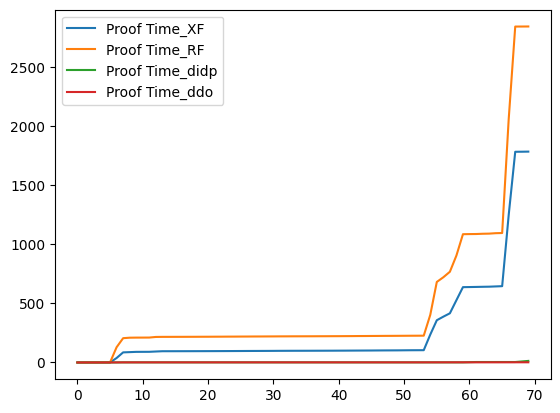

In [82]:
cum_plot(final, 'Proof Time')

0                       AFG/rbg010a.tw
1                       AFG/rbg010a.tw
2                       AFG/rbg016a.tw
3                       AFG/rbg016a.tw
4                       AFG/rbg016b.tw
                    ...               
83    SolomonPotvinBengio/rc_201.2.txt
84    SolomonPotvinBengio/rc_201.3.txt
85    SolomonPotvinBengio/rc_201.3.txt
86    SolomonPotvinBengio/rc_201.4.txt
87    SolomonPotvinBengio/rc_201.4.txt
Name: Bench, Length: 70, dtype: object


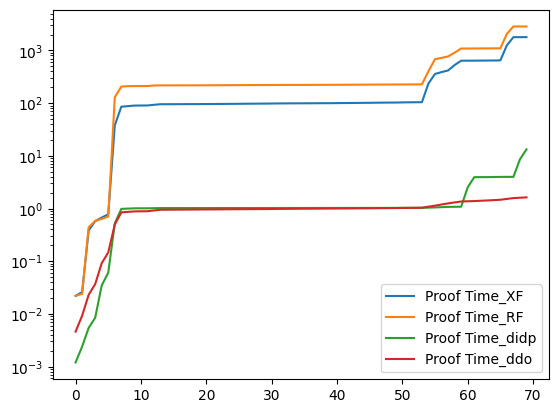

In [75]:
cum_plot(final, 'Proof Time', log=True)

0                       AFG/rbg010a.tw
1                       AFG/rbg010a.tw
2                       AFG/rbg016a.tw
3                       AFG/rbg016a.tw
4                       AFG/rbg016b.tw
                    ...               
85    SolomonPotvinBengio/rc_201.3.txt
86    SolomonPotvinBengio/rc_201.4.txt
87    SolomonPotvinBengio/rc_201.4.txt
88    SolomonPotvinBengio/rc_202.1.txt
89    SolomonPotvinBengio/rc_202.1.txt
Name: Bench, Length: 90, dtype: object


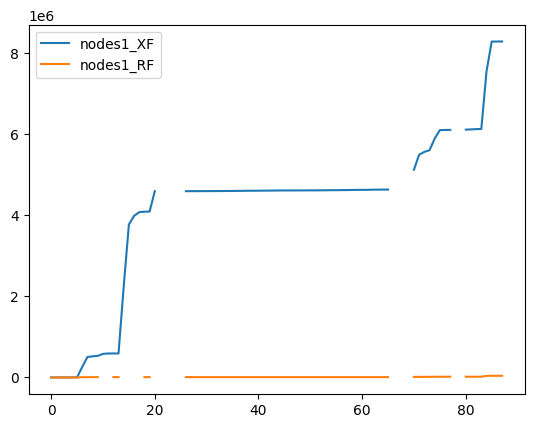

In [76]:
cum_plot(final, 'nodes1')

0                       AFG/rbg010a.tw
1                       AFG/rbg010a.tw
2                       AFG/rbg016a.tw
3                       AFG/rbg016a.tw
4                       AFG/rbg016b.tw
                    ...               
85    SolomonPotvinBengio/rc_201.3.txt
86    SolomonPotvinBengio/rc_201.4.txt
87    SolomonPotvinBengio/rc_201.4.txt
88    SolomonPotvinBengio/rc_202.1.txt
89    SolomonPotvinBengio/rc_202.1.txt
Name: Bench, Length: 90, dtype: object


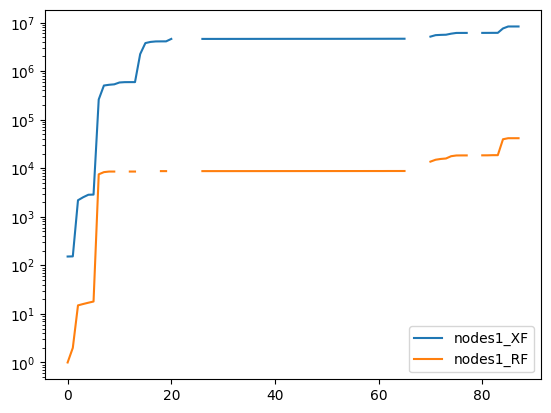

In [77]:
cum_plot(final, 'nodes1', log=True)

In [78]:
def valid_benches(exp, prefix='../data/tsptw'):
    return ' '.join([f'{prefix}/{x}' for x in exp1['Bench'].drop_duplicates()])

In [79]:
valid_benches(exp1, prefix='./resources/tsptw')

'./resources/tsptw/AFG/rbg010a.tw ./resources/tsptw/AFG/rbg016a.tw ./resources/tsptw/AFG/rbg016b.tw ./resources/tsptw/AFG/rbg017.2.tw ./resources/tsptw/AFG/rbg017.tw ./resources/tsptw/AFG/rbg017a.tw ./resources/tsptw/AFG/rbg019a.tw ./resources/tsptw/AFG/rbg019b.tw ./resources/tsptw/AFG/rbg019c.tw ./resources/tsptw/AFG/rbg019d.tw ./resources/tsptw/AFG/rbg020a.tw ./resources/tsptw/Dumas/n100w20.001.txt ./resources/tsptw/GendreauDumasExtended/n100w100.001.txt ./resources/tsptw/Langevin/N20ft301.dat ./resources/tsptw/Langevin/N20ft302.dat ./resources/tsptw/Langevin/N20ft303.dat ./resources/tsptw/Langevin/N20ft304.dat ./resources/tsptw/Langevin/N20ft305.dat ./resources/tsptw/Langevin/N20ft306.dat ./resources/tsptw/Langevin/N20ft307.dat ./resources/tsptw/Langevin/N20ft308.dat ./resources/tsptw/Langevin/N20ft309.dat ./resources/tsptw/Langevin/N20ft310.dat ./resources/tsptw/Langevin/N20ft401.dat ./resources/tsptw/Langevin/N20ft402.dat ./resources/tsptw/Langevin/N20ft403.dat ./resources/tsptw/L

In [80]:
valid_benches(exp1)

'../data/tsptw/AFG/rbg010a.tw ../data/tsptw/AFG/rbg016a.tw ../data/tsptw/AFG/rbg016b.tw ../data/tsptw/AFG/rbg017.2.tw ../data/tsptw/AFG/rbg017.tw ../data/tsptw/AFG/rbg017a.tw ../data/tsptw/AFG/rbg019a.tw ../data/tsptw/AFG/rbg019b.tw ../data/tsptw/AFG/rbg019c.tw ../data/tsptw/AFG/rbg019d.tw ../data/tsptw/AFG/rbg020a.tw ../data/tsptw/Dumas/n100w20.001.txt ../data/tsptw/GendreauDumasExtended/n100w100.001.txt ../data/tsptw/Langevin/N20ft301.dat ../data/tsptw/Langevin/N20ft302.dat ../data/tsptw/Langevin/N20ft303.dat ../data/tsptw/Langevin/N20ft304.dat ../data/tsptw/Langevin/N20ft305.dat ../data/tsptw/Langevin/N20ft306.dat ../data/tsptw/Langevin/N20ft307.dat ../data/tsptw/Langevin/N20ft308.dat ../data/tsptw/Langevin/N20ft309.dat ../data/tsptw/Langevin/N20ft310.dat ../data/tsptw/Langevin/N20ft401.dat ../data/tsptw/Langevin/N20ft402.dat ../data/tsptw/Langevin/N20ft403.dat ../data/tsptw/Langevin/N20ft404.dat ../data/tsptw/Langevin/N20ft405.dat ../data/tsptw/Langevin/N20ft406.dat ../data/tsptw/L